# Occurrence rate

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from scipy.stats import gaussian_kde

In [3]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.planets import OccurrenceRate

In [4]:
np.random.seed(42)

In [5]:
occ_rate = OccurrenceRate(primary_mass=np.full(1000, 1.0), occ_rate="gpi_nielsen2019")
sma, mass_planet = occ_rate.sample_planets(allow_reject=False)


---------------
Occurrence rate
---------------

Occurrence rate: gpi_nielsen2019

Valid ranges:
   - Semi-major axis (au): 10.00 - 100.00
   - Companion mass (Mjup): 5.00 - 13.00

Primary mass range (Msun): 1.00 - 1.00

--------------
Sample planets
--------------

Number of stars: 1000
Number of planets: 1000

Semi-major axis range (au) = 10.01 - 99.95
Companion mass range (Mjup) = 5.00 - 12.99


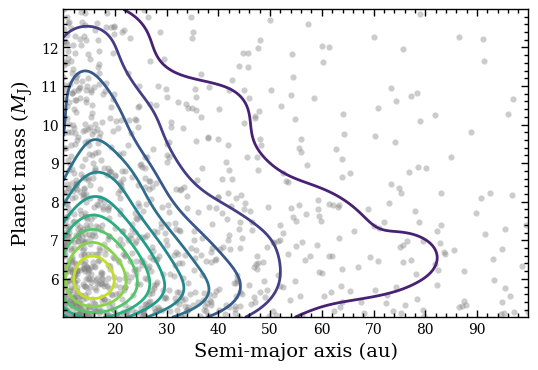

In [6]:
xy = np.vstack([sma, mass_planet])
kde = gaussian_kde(xy)

x_points = np.linspace(np.min(sma), np.max(sma), 200)
y_points = np.linspace(np.min(mass_planet), np.max(mass_planet), 200)
x_grid, y_grid = np.meshgrid(x_points, y_points)

positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = kde(positions).reshape(x_grid.shape)

plt.figure(figsize=(6, 4))
plt.scatter(sma, mass_planet, s=20, alpha=0.4, lw=0.0, color="gray")
plt.contour(x_grid, y_grid, z_grid, levels=10, linewidths=2.0)
plt.xlabel("Semi-major axis (au)", fontsize=14)
plt.ylabel("Planet mass ($M_\mathrm{J}$)", fontsize=14)
plt.show()

In [7]:
source_id = 6643589352010758400  # HD 181327
primary_mass = (1.36, 0.02)  # (Msun)

In [8]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR5')


----------------
Epoch astrometry
----------------

Gaia release: DR5
Reference epoch: 2020.0

Primary mass (Msun): 1.36 +/- 0.02


In [9]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 6643589352010758400

INFO: Query finished. [astroquery.utils.tap.core]

RA = 290.746 deg +/- 0.018 mas
Dec = -54.538 deg +/- 0.018 mas
Parallax = 20.931 +/- 0.029 mas
Proper motion in RA = 24.403 +/- 0.022 mas/yr
Proper motion in Dec = -82.186 +/- 0.016 mas/yr
G-band magnitude = 6.936
Pseudocolor = 1.61 um-1

UWE = 1.68
RUWE = 0.96
Astrometric excess noise (mas) = 0.1376 +/- 0.0074
Non single star = 0


In [10]:
model_param = epoch_astrom.simulate_data(mass_2=None, sma=None, ecc=None, inc=None, aop=None, pan=None, tau=None,
                                         sigma_per_ccd=None, csv_out=None,
                                         ra=None, dec=None, parallax=None, pmra=None, pmdec=None,
                                         phot_g_mean_mag=None, occ_rate="gpi_nielsen2019")


---------------
Occurrence rate
---------------

Occurrence rate: gpi_nielsen2019

Valid ranges:
   - Semi-major axis (au): 10.00 - 100.00
   - Companion mass (Mjup): 5.00 - 13.00

Primary mass range (Msun): 1.36 - 1.36

--------------
Sample planets
--------------

Number of stars: 1
Number of planets: 1

Semi-major axis (au) = 24.41
Companion mass (Mjup) = 9.63

-------------
Simulate data
-------------

System type: binary

AL scan uncertainty (per CCD) = 158.77 uas
AL scan uncertainty (per transit) = 56.14 uas

Stellar parameters:
   - RA (deg) = 290.75
   - Dec (deg) = -54.54
   - Parallax (mas) = 20.93
   - Proper motion in RA (mas/yr) = 24.40
   - Proper motion in Dec (mas/yr) = -82.19
   - G-band magnitude = 6.94

Orbit parameters:
   - Primary mass (Msun) = 1.36
   - Companion mass (Mjup) = 9.63
   - Relative semi-major axis (au) = 24.41
   - Eccentricity = 0.10
   - Inclination (deg) = 127.92
   - Argument of periastron (deg) = 42.13
   - PA of ascending node (deg) = 146.39


In [11]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 1.367
RUWE = 1.169
F2 estimator = 2.827
Inflation factor = 1.172

Best-fit parameters:
   - RA offset = -0.930 +/- 0.008 mas
   - Dec offset = 3.128 +/- 0.007 mas
   - Parallax = 20.928 +/- 0.010 mas
   - mu in RA = 24.259 +/- 0.003 mas/yr
   - mu in Dec = -82.154 +/- 0.003 mas/yr


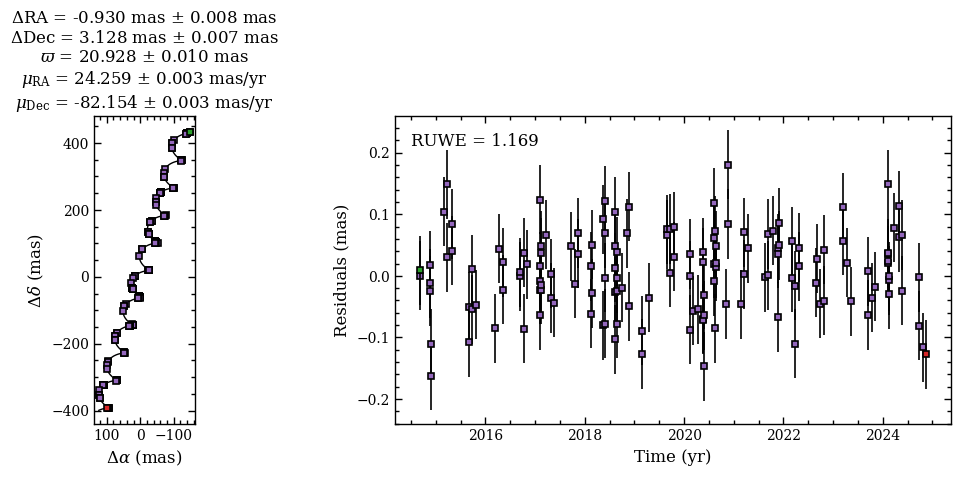

In [12]:
results = leastsq.singl_5param(plot_file='plot.png')


--------------------------
Binary star (7 parameters)
--------------------------

Reduced chi^2 = 0.954
RUWE = 0.977
F2 estimator = -0.356
Inflation factor = 0.979
Significance dmu/dt = 7.814

Best-fit parameters:
   - RA offset = -0.939 +/- 0.010 mas
   - Dec offset = 3.173 +/- 0.009 mas
   - Parallax = 20.935 +/- 0.010 mas
   - mu in RA = 24.256 +/- 0.002 mas/yr
   - mu in Dec = -82.157 +/- 0.002 mas/yr
   - dmu/dt in RA = 0.001 +/- 0.002 mas/yr^2
   - dmu/dt in Dec = -0.012 +/- 0.002 mas/yr^2


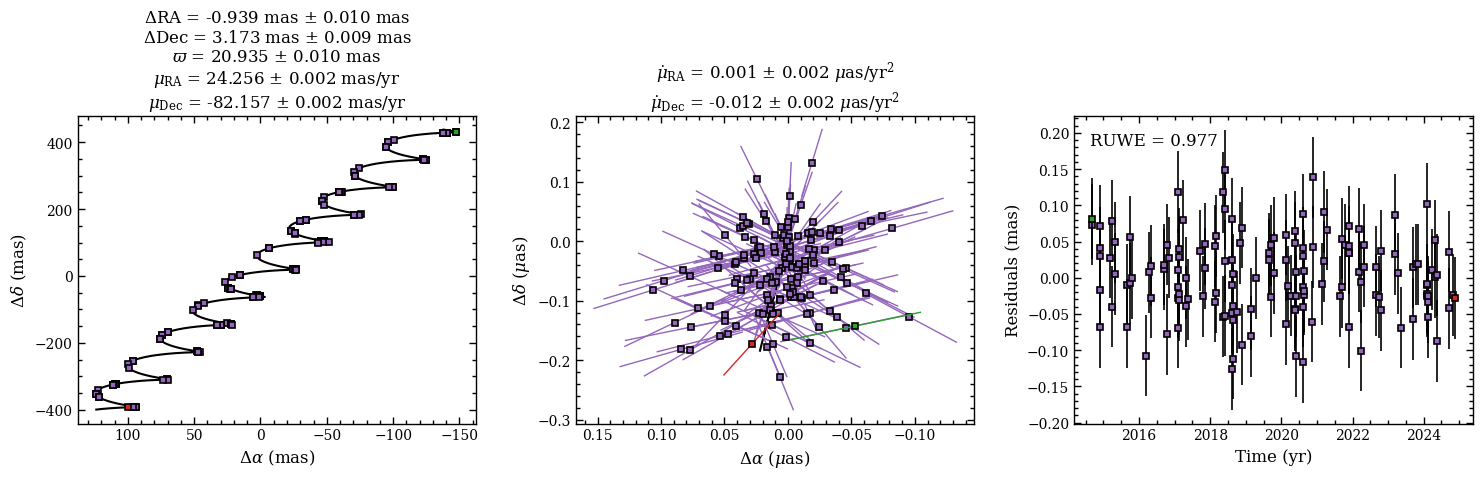

In [13]:
results = leastsq.accel_7param(plot_file='plot.png')